In [2]:
import pandas as pd
import numpy as np
import torch

In [41]:
from collections import Counter


In [ ]:
sente = "Ja sam sam sam sigma"


In [3]:
train = pd.read_csv("train.csv")
train

,img,label
0,\\/\\\\?—\\ccccc/ccccco\P/c;.|o\ooPPPPPPP/PPPP...,32
1,\P/P|\\\ooo||o—||\\@/■\■■■\\■■——\\■■\||■\@\\/|...,32
2,\\\\\\/—\—/c/|\|c\cccc/\c\/|\/c\c/|cc—/—/\//\/...,34
3,—/—////??@@■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■...,24
4,\\/\/\\///\\/\/\|c\|o/o||/|\\..../c\ ...,19
...,...,...
3675,\——PP/———————\——|\c;..;ccooooooooooooooooooooo...,25
3676,c/////\|\\\/c\c\|;;c//———\@//\o/\\/\|\/—|—/\\\...,28
3677,..... ..;|;;;;.....,28
3678,../.;....;;;/;|;|;;;;/.;;.;;...—.........;\\o|...,8


In [36]:
train.img[66].split("\n")

['|\\/\\|/c/—//|———\\\\\\\\\\\\\\\\\\\\\\\\|\\\\\\/||/./.\\/.. \\../\\/\\\\ |/.//|||\\/\\\\\\/;\\—\\\\\\\\///\\|||//\\\\\\|\\\\\\\\\\|\\|||||/||\\|\\/|;|\\;\\//\\||||;//\\\\/\\\\\\|',
 '\\\\///|////;////\\\\|||P\\/\\\\\\\\\\\\\\\\\\\\\\\\.|\\.\\|\\/./||\\/\\\\\\| //\\\\\\/—\\\\\\//——\\;;;;\\/\\//|//\\/\\\\\\/\\\\|\\\\|\\/||||\\\\\\\\/|\\;//\\;|//;/||;//P/|\\\\\\/',
 '\\\\//O////c;/////\\\\||P\\|\\\\\\\\\\\\\\c\\\\\\\\\\.\\/\\...\\\\\\\\|.\\.||.|..  \\/|/////\\\\\\—\\\\\\/\\\\|//\\\\||\\/\\/|\\\\\\/\\\\|||||\\\\\\\\\\c;\\/|;\\\\////||//\\||\\\\\\\\',
 '\\//|O///c//////|/|||P|\\/\\\\\\O\\\\;|/\\\\/\\;\\\\\\./\\\\/;|\\..|.|/\\ /\\\\/\\//c/\\\\|//\\\\\\.;///\\\\\\/\\\\\\|/\\|\\c\\|\\||||\\\\\\\\|||\\/;\\/\\\\//|||//\\\\/\\\\\\\\|',
 ';|\\////c///////|\\/||||\\\\\\\\\\\\\\\\\\|\\O|\\|\\./\\.\\\\\\—//\\/./—|\\.\\\\\\\\//—||\\.\\\\/.\\\\|.|\\|/\\//|\\|;/\\\\\\\\;||\\|||\\|\\\\\\\\\\c;/\\\\|;;//|||||\\\\\\\\;|\\;',
 ';|\\//cc//c////\\/c\\||P/|/\\\\\\\\P\\\\\\\\/—\\\\/;\\\\\\\\\\///\\\\\\\\/.\\

In [ ]:
sigma = {
  
    " ":"0"
}
data = train["img"].apply(lambda x : [[int(i) for i in "".join({Counter(list(xp)).most_common(1)[0][0]:"0"}.get(ch,"1") for ch in xp)] for xp in x.split("\n")])
data

In [47]:
list("awda dawdawd")

['a', 'w', 'd', 'a', ' ', 'd', 'a', 'w', 'd', 'a', 'w', 'd']

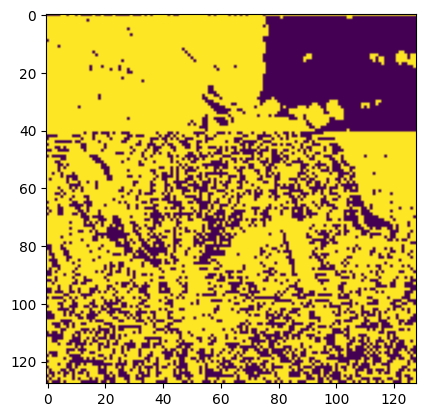

In [57]:
import matplotlib.pyplot as plt

plt.imshow(np.array(data[43]))
plt.show()

In [65]:
dataset = torch.utils.data.TensorDataset(torch.tensor(data[:int(0.8*train.shape[0])],dtype=torch.float32),torch.tensor(train.loc[:int(0.8*train.shape[0]),"label"].astype("int"),dtype=torch.long))

In [77]:
data = [np.expand_dims(np.array(j),axis=0) for j in data]
data

[array([[[[1],
          [1],
          [1],
          ...,
          [1],
          [1],
          [1]],
 
         [[1],
          [1],
          [1],
          ...,
          [1],
          [1],
          [1]],
 
         [[1],
          [1],
          [1],
          ...,
          [1],
          [1],
          [1]],
 
         ...,
 
         [[1],
          [1],
          [0],
          ...,
          [0],
          [1],
          [1]],
 
         [[1],
          [1],
          [1],
          ...,
          [1],
          [1],
          [1]],
 
         [[1],
          [1],
          [0],
          ...,
          [1],
          [1],
          [1]]]], shape=(1, 128, 128, 1)),
 array([[[[1],
          [1],
          [1],
          ...,
          [0],
          [0],
          [1]],
 
         [[1],
          [1],
          [1],
          ...,
          [0],
          [0],
          [0]],
 
         [[1],
          [1],
          [1],
          ...,
          [1],
          [0],
     

In [75]:
import torch.nn as nn
class MLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(1,16,4),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(4),
             torch.nn.Conv2d(16,32,4),
             torch.nn.ReLU(),
            torch.nn.AdaptiveMaxPool2d((32,32)),
            torch.nn.Linear(32*32*32,600),
            torch.nn.ReLU(),
            torch.nn.Linear(600,train["label"].nunique())
        )
    def forward(self,x):
        return self.net(x)
model = MLP()
criterion = nn.CrossEntropyLoss()
loader = torch.utils.data.DataLoader(dataset,batch_size=32,shuffle=True)
optim = torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-3)
for epoch in range(10):
    for image,target in loader:
        out = model(image)
        loss = criterion(out,target)
        optim.zero_grad()
        loss.backward()
        optim.step()
    print(f"Epoch {epoch}")

RuntimeError: Given groups=1, weight of size [16, 1, 4, 4], expected input[1, 32, 128, 128] to have 1 channels, but got 32 channels instead

In [63]:
train.loc[:int(0.8*train.shape[0]),"label"].astype("int")

0       32
1       32
2       34
3       24
4       19
        ..
2940    12
2941    12
2942    13
2943    24
2944    36
Name: label, Length: 2945, dtype: int64

In [ ]:

sigma.get("@",1)

1

In [60]:
train["label"].nunique()

37

In [12]:
y =4
3 if y==4 else 4

3